In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt 

# Comprobar la version de PyTorch
torch.__version__

'2.11.0+cpu'

In [2]:
# Crear nuevos parametros
volumen = 0.8
sesgo = 0.2

# Crear datos
inicio = 0
final = 1
step = 0.025
X = torch.arange(inicio, final, step).unsqueeze(dim=1)
print(f"Shape de X: {X.shape}")
y = volumen * X + sesgo
print(f"Shape de y: {y.shape}")

X[:10], y[:10]

Shape de X: torch.Size([40, 1])
Shape de y: torch.Size([40, 1])


(tensor([[0.0000],
         [0.0250],
         [0.0500],
         [0.0750],
         [0.1000],
         [0.1250],
         [0.1500],
         [0.1750],
         [0.2000],
         [0.2250]]),
 tensor([[0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800]]))

Necesitamos un conjunto de prueba y uno de entrenamiento

Cada conjunto tiene un objetivo especifico:
 - Conjunto de entrenamiento: El modelo aprende de los datos
 - Conjunto de prueba: El modelo se evalua con los datos para probar lo que ha aprendido

In [3]:
# Crea la division

train_division = int(0.7 * len(X)) # 70% de los datos utilizados para el conjunto de entrenamiento, 30% para pruebas
X_train, y_train = X[:train_division], y[:train_division]
X_prueba, y_prueba = X[train_division:], y[train_division:]


In [4]:
len(X_train), len(X_prueba)

(28, 12)

Tenemos 28 muestras para entrenamiento (X_train, y_train) y 12 muestras de prueba (X_prueba, y_prueba)

Visualizamos nuestros datos

In [5]:
def plot_predictions(datos_ent=X_train, etiq_ent = y_train, datos_prueba=X_prueba, etiq_prueba = y_prueba, predictions = None):
    """
    Traza datos de entrenamiento, datos de prueba y compara predicciones
    """
    plt.figure(figsize=(10, 10))

    # Traza datos de entrenamiento en verde
    plt.scatter(datos_ent, etiq_ent, c="g", s = 6, label="Datos de entrenamiento")

    # Traza datos de prueba en amarillo
    plt.scatter(datos_prueba, etiq_prueba, c="y", s=6, label= "Datos prueba")

    if predictions is not None:
        # Traza las predicciones en rojo
        plt.scatter(datos_prueba, predictions, c="r", s=6, label="Predicciones")

    # Leyenda
    plt.legend(prop={"size":12});

In [6]:
plot_predictions

<function __main__.plot_predictions(datos_ent=tensor([[0.0000],
        [0.0250],
        [0.0500],
        [0.0750],
        [0.1000],
        [0.1250],
        [0.1500],
        [0.1750],
        [0.2000],
        [0.2250],
        [0.2500],
        [0.2750],
        [0.3000],
        [0.3250],
        [0.3500],
        [0.3750],
        [0.4000],
        [0.4250],
        [0.4500],
        [0.4750],
        [0.5000],
        [0.5250],
        [0.5500],
        [0.5750],
        [0.6000],
        [0.6250],
        [0.6500],
        [0.6750]]), etiq_ent=tensor([[0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
       

# 2. Estructura de un modelo Pytorch


Construyamos un modelo de regresión lineal utilizando PyTorch.

`torch.nn` proporciona herramientas para construir redes neuronales, `torch.optim` para optimizar los modelos, `data.Dataset` para manejar los conjuntos de datos y `torch.utils.data.DataLoader` para cargar y transformar los datos. Estas herramientas son fundamentales para la construcción y entrenamiento de modelos de machine learning.

* `torch.nn`: es un módulo que proporciona clases y funciones para construir redes neuronales. Contiene una variedad de capas, como capas de convolución, capas de agrupación, capas de normalización, capas recurrentes y capas completamente conectadas, que se pueden combinar para construir una variedad de arquitecturas de redes neuronales.

* `torch.optim`: proporciona clases y funciones para optimizar los modelos de machine learning. Contiene una variedad de algoritmos de optimización, como SGD, Adam, Adagrad y Adadelta, que se utilizan para ajustar los parámetros de los modelos durante el entrenamiento.

* `torch.utils.data.Dataset`: es una clase que se utiliza para representar conjuntos de datos de machine learning. Proporciona una interfaz consistente para acceder a los datos y sus etiquetas. Se puede personalizar para trabajar con conjuntos de datos de diferentes formatos y tipos.

* `torch.utils.data.DataLoader`: es una clase que se utiliza para cargar y transformar datos de un conjunto en lotes para el entrenamiento de modelos. Se encarga de la asignación de los lotes, la mezcla de los datos y la carga de los datos en la GPU si es necesario, lo que facilita el procesamiento de grandes conjuntos de datos.

Por el momento, vamos a utilizar los dos primeros módulos. En el proyecto final usaremos `DataLoader`.

El siguiente fragmento define una clase llamada `ModeloRegresionLineal` que hereda de la clase `nn.Module` en PyTorch. 

La clase tiene dos parámetros ajustables (`volumen` y `sesgo`) que se inicializan con valores aleatorios y se pueden optimizar durante el entrenamiento. 

La función `forward` realiza el cálculo del modelo, donde se multiplica el tensor de entrada `x` por el parámetro `volumen` y se le agrega el parámetro `sesgo`.

En resumen, este código define una clase de modelo de regresión lineal con dos parámetros ajustables y define la operación de cálculo del modelo. Esto se utiliza como una plantilla para definir y entrenar modelos de regresión lineal en PyTorch.

In [7]:
# Crea una clase de modelo de regresion lineal
class ModeloRegresionLineal(nn.Module):
    def __init__(self):
        super().__init__()
        self.volumen = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.sesgo = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

# Define el calculo en el modelo
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.volumen * x + self.sesgo

`torch.manual_seed(42)` establece la semilla del generador de números aleatorios en 42. Lo que significa que los mismos números aleatorios se generarán en cada ejecución del código que utilice tensores de PyTorch. 

Esto puede ser útil para reproducir resultados y garantizar la reproducibilidad de los experimentos de machine learning.

In [8]:
torch.manual_seed(42)

# Crea un objeto instanciando la clase ModeloRegresionLineal
model_1 = ModeloRegresionLineal()

In [9]:
model_1

ModeloRegresionLineal()

In [10]:
model_1.state_dict()

OrderedDict([('volumen', tensor([0.3367])), ('sesgo', tensor([0.1288]))])

### Predicciones usando `torch.inference_mode()`

Para hacer predicciones con `torch.inference_mode()` podemos pasar los datos de prueba `X_prueb` para ver qué tan cerca pasan de `y_prueb`.

Cuando pasemos datos al modelo, pasarán por `forward()` produciendo un resultado con el cálculo que definimos anteriormente.

In [11]:
# Hacer predicciones con el modelo
with torch.inference_mode():
    y_predc = model_1(X_prueba)

In [12]:
# Comprueba las predicciones
y_predc

tensor([[0.3645],
        [0.3729],
        [0.3813],
        [0.3897],
        [0.3982],
        [0.4066],
        [0.4150],
        [0.4234],
        [0.4318],
        [0.4402],
        [0.4487],
        [0.4571]])

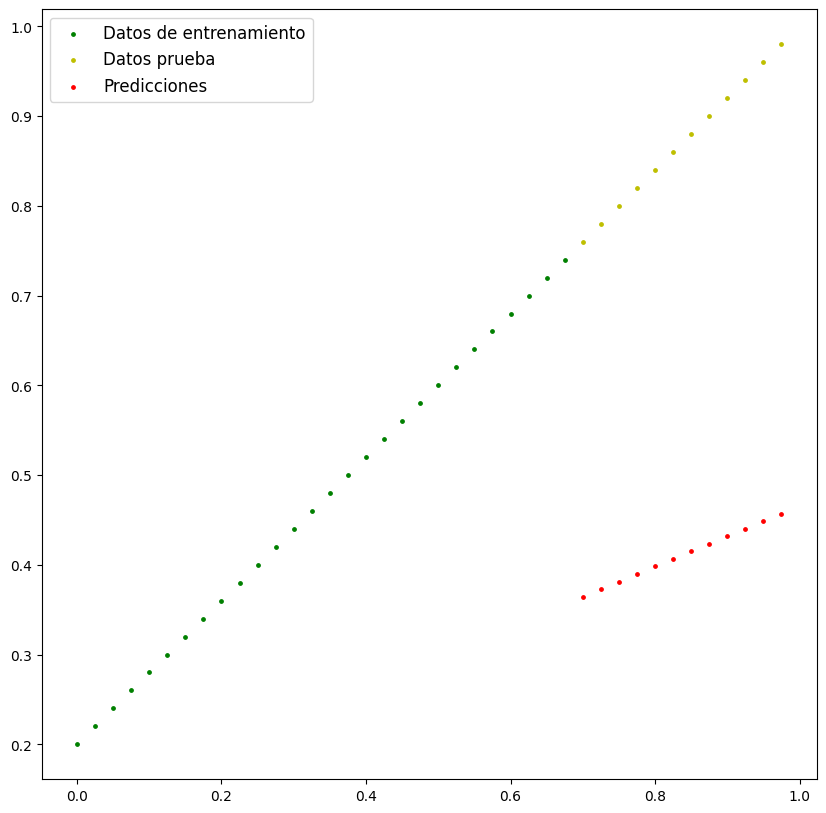

In [13]:
plot_predictions(predictions=y_predc)

# 3. Aplicación de función de pérdida y optimizadores en PyTorch

##### Para arreglar los valores aleatorios de los parámetros del modelo podemos actualizar los parámetros internos de las variables `# volumen` y `# sesgo` para representar mejor los datos.

Para ello, crearemos una **función de pérdida** así como un **optimizador** con PyTorch.

> La `# función de pérdida` mide qué tan equivocadas están las predicciones del modelo `# y_predc`, en comparación con las etiquetas `# y_prueb`. PyTorch tiene muchas funciones de pérdida integradas en `#torch.nn`.


> El `#optimizador` le indica a los modelos cómo actualizar sus parámetros internos para reducir la pérdida. Podemos encontrar varias implementaciones en `#torch.optim`.

Dependiendo del tipo de problema que estemos trabajando vamos a emplear una determinada función de pérdida y optimización.

Para nuestro problema utilizaremos el **Error Cuadrático Medio (MAE)** como la función de pérdida `(torch.nn.L1Loss)` para medir la diferencia absoluta entre dos puntos y tomar la media en todos los ejemplos.

También usaremos **Stochastic Gradient Descent (SGD)** `(torch.optim.SGD(params, lr))` como nuestro optimizador, donde `# params` son los parámetros del modelo (volumen y sesgo) y `# lr` es la tasa de aprendizaje a la que desea que el optimizador actualice los parámetros.

Además, fijamos arbitrariamente una tasa de aprendizaje de 0.01


In [14]:
# Crea funcion de perdida
fn_perdida = torch.nn.L1Loss()

# Crea el optimizador
optimizador = torch.optim.SGD(params=model_1.parameters(), lr=0.01)

In [15]:
optimizador

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

Ya que tenemos una función de pérdida y un optimizador, vamos a crear un ciclo de entrenamiento y uno de prueba. Esto implica que el modelo pase por los datos de entrenamiento y aprenda la relación entre `features` y `labels`.

El ciclo de prueba implica revisar los datos de prueba y evaluar qué tan buenos son los patrones que el modelo aprendió de los datos de entrenamiento.

Para entrenar, vamos a escribir un bucle `for` de Python.


### Bucle de entrenamiento:

**Pasos a seguir:**

1.  El modelo pasa por todos los datos de entrenamiento nuevamente, realizando sus cálculos en funciones `forward ()`. *Código:* `modelo(X_ent)`
2. Las predicciones se comparan  y se evalúan para ver qué tan equivocadas están. *Código:* `perdida = fn_perd(y_predc, y_ent)`.
3. Los gradientes de los optimizadores se establecen en cero para que puedan recalcularse y dar paso al entrenamiento específico. *Código:* `optimizer.zero_grad()`.
4. Se calcula la pérdida del gradiente con respecto a cada parámetro que se actualizará (retroprogramación). *Código:* `loss.backward()`.
5. Se actualizan los parámetros con `requires_grand=True` respecto a la pérdida para mejorarlos. *Código:* `optimizer.step()`.

In [16]:
torch.manual_seed(42)

# Establezca cuantas veces el modelo pasara por los datos de entrenamiento
epocas = 200

# Cree listas vacias para realizar un seguimiento de nuestro modelo
entrenamiento_loss = []
test_loss = []

for epoca in range(epocas):
    ### Entrenamiento

    # 1. pase hacia adelante los datos usando el metodo forward()
    y_pred = model_1(X_train)

    # 2. Calcula la perdida
    perdida = fn_perdida(y_pred, y_train)

    # 3. Gradiente cero del optimizador
    optimizador.zero_grad()

    # 4. Backpropagation
    perdida.backward()

    # 5. Actualiza los pesos
    optimizador.step()

    ### Funcion de prueba
    model_1.eval()

    # 1. reenviar datos de prueba
    prueba_predc = model_1(X_prueba)

    # 2. Calcular la perdida en datos de prueba
    prueb_perd = fn_perdida(prueba_predc, y_prueba.type(torch.float))

    